In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
csv_path = "Names_hints/dpt2020.csv"
df = (
    pd.read_csv(csv_path, sep=";")
      .query("preusuel != '_PRENOMS_RARES'")
      .astype({"dpt": str})
)

df = df[df["annais"] != "XXXX"]

df.head()

,sexe,preusuel,annais,dpt,nombre
10885,1,AADIL,1983,84,3
10886,1,AADIL,1992,92,3
10888,1,AAHIL,2016,95,3
10892,1,AARON,1962,75,3
10893,1,AARON,1976,75,3


In [4]:
df["sexe"].value_counts()

sexe
2    1966210
1    1702064
Name: count, dtype: int64

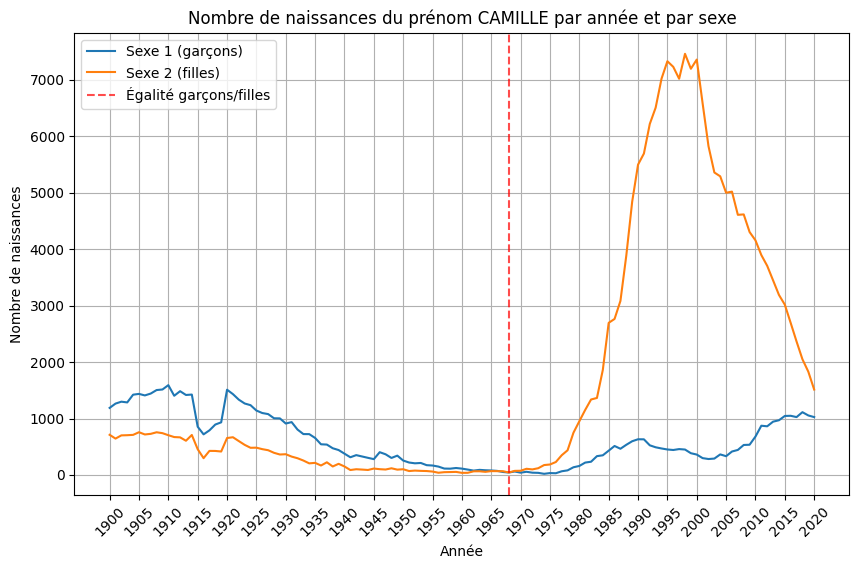

In [8]:
prenom = "CAMILLE"

data_prenom = df[df["preusuel"] == prenom]

data_grouped = data_prenom.groupby(["annais", "sexe"])["nombre"].sum().unstack(fill_value=0)


for sexe in [1, 2]:
    if sexe not in data_grouped.columns:
        data_grouped[sexe] = 0
data_grouped = data_grouped[[1, 2]]

plt.figure(figsize=(10, 6))

plt.plot(data_grouped.index, data_grouped.get(1, pd.Series()), label="Sexe 1 (garçons)")
plt.plot(data_grouped.index, data_grouped.get(2, pd.Series()), label="Sexe 2 (filles)")

equal_years = data_grouped.index[data_grouped[1] == data_grouped[2]]
for year in equal_years:
    plt.axvline(x=year, color='red', linestyle='--', alpha=0.7, label="Égalité garçons/filles" if year == equal_years[0] else "")

plt.xlabel("Année")
plt.ylabel("Nombre de naissances")
plt.title(f"Nombre de naissances du prénom {prenom} par année et par sexe")
plt.legend()
plt.grid()

xticks = data_grouped.index[::5]
plt.xticks(xticks, rotation=45)

plt.show()